In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm
import yfinance as yf
import pandas_datareader.data as web
import datetime
import requests
import seaborn as sns

In [109]:
from scipy.stats import norm
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [4]:
merged_data = pd.read_csv('merged_data.csv')

In [7]:
merged_data.head()

,Unnamed: 0,date,underlying_price,implied_volatility,risk_free_rate
0,0,2024-04-30,501.98,0.1565,5.25
1,1,2024-05-01,500.35,0.1539,5.26
2,2,2024-05-02,505.03,0.1468,5.25
3,3,2024-05-03,511.29,0.1349,5.25
4,4,2024-05-06,516.57,0.1349,5.25


In [9]:
merged_data.describe()

,Unnamed: 0,underlying_price,implied_volatility,risk_free_rate
count,253.000000,253.000000,253.000000,253.000000
mean,126.000000,565.170474,0.181579,4.630158
std,73.179004,28.127478,0.060426,0.430384
min,0.000000,496.480000,0.118600,4.170000
25%,63.000000,544.510000,0.142800,4.220000
50%,126.000000,563.980000,0.164300,4.480000
75%,189.000000,590.300000,0.199000,5.140000
max,252.000000,612.930000,0.523300,5.260000


In [13]:
merged_data['date'] = pd.to_datetime(merged_data['date'])

In [15]:
merged_data['rate'] = merged_data['risk_free_rate'] / 100

In [17]:
merged_data.head()

,Unnamed: 0,date,underlying_price,implied_volatility,risk_free_rate,rate
0,0,2024-04-30,501.98,0.1565,5.25,0.0525
1,1,2024-05-01,500.35,0.1539,5.26,0.0526
2,2,2024-05-02,505.03,0.1468,5.25,0.0525
3,3,2024-05-03,511.29,0.1349,5.25,0.0525
4,4,2024-05-06,516.57,0.1349,5.25,0.0525


In [111]:
CURVATURE = 0.20    
SKEW      = -0.25   
SKEW_DECAY   = 1.0     
NOISE_STD = 0.005 
OPTION_TYPE = 'call'

In [47]:
# MONEYNESS = np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20])
# MATURITIES = np.array([21/252, 42/252, 63/252, 126/252, 189/252, 252/252])
 
# np.random.seed(42)

In [113]:
def synthetic_iv(base_iv, E, S, T,
                 curvature=CURVATURE, skew=SKEW,
                 skew_decay=SKEW_DECAY, noise_std=NOISE_STD):

    x              = np.log(E / S)
    curvature_term = curvature * x**2
    skew_term      = skew * x * np.exp(-skew_decay * T)
    noise          = np.random.normal(0, noise_std)
    iv             = base_iv + curvature_term + skew_term + noise
    iv = float(np.clip(iv, 0.03, 1.50))
    return iv 

In [115]:
def bs_price(S, E, T, r, sigma, option_type=OPTION_TYPE):
    if T < 1e-6 or sigma < 1e-6:
        return max(S - E, 0) if option_type == 'call' else max(E - S, 0)
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*norm.cdf(d1) - E*np.exp(-r*T)*norm.cdf(d2)
    return E*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

def bs_delta(S, E, T, r, sigma, option_type = OPTION_TYPE):
    if T < 1e-6 or sigma < 1e-6:
        return 1.0 if (option_type == 'call' and S > E) else 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1) if option_type == 'call' else norm.cdf(d1) - 1

def bs_vega(S, E, T, r, sigma):
    if T < 1e-6 or sigma < 1e-6: return 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def bs_gamma(S, E, T, r, sigma):
    if T < 1e-6 or sigma < 1e-6: return 0.0
    d1 = (np.log(S/E) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

In [121]:
def create_synthetic_option_panel(
    merged_data,
    moneyness_grid=np.array([0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]),
    maturities=np.array([21/252, 42/252, 63/252, 126/252, 189/252, 252/252]),
    issue_every_n_days=5,
    min_days_to_expiry=14, # get rid of data of last 14 days
    seed=42
):
    
    df = merged_data.copy()
    df = df.sort_values("date").reset_index(drop=True)
    df["date"] = pd.to_datetime(df["date"])

    rng = np.random.default_rng(seed)
    records = []

    for issue_idx in range(0, len(df), issue_every_n_days):
        issue_row = df.iloc[issue_idx]
        issue_date = issue_row["date"]
        S_issue = float(issue_row["underlying_price"])

        strikes = S_issue * moneyness_grid

        for T0 in maturities:
            max_days_expiry = int(round(T0 * 252))

            for E in strikes:
                option_id = f"{issue_date.date()}|E={E:.4f}|T0={int(round(T0*252))}"

                for j in range(max_days_expiry + 1):
                    time_elapse_idx = issue_idx + j
                    if time_elapse_idx >= len(df):
                        break

                    tau = T0 - j / 252.0
                    if tau < min_days_to_expiry / 252.0:
                        break

                    row = df.iloc[time_elapse_idx]
                    date = row["date"]
                    S = float(row["underlying_price"])
                    base_iv = float(row["implied_volatility"])
                    r = float(row["rate"])

                   

                    sigma = synthetic_iv(
                        base_iv=base_iv,
                        E=E,
                        S=S,
                        T=tau
                        )

                    price = bs_price(S, E, tau, r, sigma)
                    delta = bs_delta(S, E, tau, r, sigma)
                    vega = bs_vega(S, E, tau, r, sigma)
                    gamma = bs_gamma(S, E, tau, r, sigma)

                    records.append({
                        "option_id": option_id,
                        "issue_date": issue_date,
                        "date": date,
                        "issue_idx": issue_idx,
                        "time_elapse_idx": time_elapse_idx,
                        "days_since_issue": j,
                        "strike": E,
                        "initial_T": T0,
                        "tau": tau,
                        "underlying_price": S,
                        "rate": r,
                        "implied_vol": sigma,
                        "option_price": price,
                        "delta_bs": delta,
                        "vega_bs": vega,
                        "gamma_bs": gamma
                    })

    panel = pd.DataFrame(records)
    panel = panel.sort_values(["option_id", "date"]).reset_index(drop=True)
    return panel

In [125]:
panel = create_synthetic_option_panel(
    merged_data,
    issue_every_n_days=5
)



(189009, 16)


,option_id,issue_date,date,issue_idx,time_elapse_idx,days_since_issue,strike,initial_T,tau,underlying_price,rate,implied_vol,option_price,delta_bs,vega_bs,gamma_bs
0,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-04-30,0,0,0,401.584,0.5,0.500000,501.98,0.0525,0.196962,111.700668,0.968580,25.094696,0.001011
1,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-01,0,1,1,401.584,0.5,0.496032,500.35,0.0526,0.189301,109.858359,0.972040,22.614478,0.000962
2,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-02,0,2,2,401.584,0.5,0.492063,505.03,0.0525,0.191776,114.354584,0.975181,20.579406,0.000855
3,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-03,0,3,3,401.584,0.5,0.488095,511.29,0.0525,0.182915,120.244871,0.984395,13.995212,0.000600
4,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-06,0,4,4,401.584,0.5,0.484127,516.57,0.0525,0.186107,125.400080,0.986291,12.596735,0.000524


In [126]:
print(panel.shape)
panel.head()

(189009, 16)


,option_id,issue_date,date,issue_idx,time_elapse_idx,days_since_issue,strike,initial_T,tau,underlying_price,rate,implied_vol,option_price,delta_bs,vega_bs,gamma_bs
0,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-04-30,0,0,0,401.584,0.5,0.500000,501.98,0.0525,0.196962,111.700668,0.968580,25.094696,0.001011
1,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-01,0,1,1,401.584,0.5,0.496032,500.35,0.0526,0.189301,109.858359,0.972040,22.614478,0.000962
2,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-02,0,2,2,401.584,0.5,0.492063,505.03,0.0525,0.191776,114.354584,0.975181,20.579406,0.000855
3,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-03,0,3,3,401.584,0.5,0.488095,511.29,0.0525,0.182915,120.244871,0.984395,13.995212,0.000600
4,2024-04-30|E=401.5840|T0=126,2024-04-30,2024-05-06,0,4,4,401.584,0.5,0.484127,516.57,0.0525,0.186107,125.400080,0.986291,12.596735,0.000524


In [130]:
def add_contract_diff(panel):
    df = panel.copy()
    df = df.sort_values(["option_id", "date"]).reset_index(drop=True)

    df["dV"] = df.groupby("option_id")["option_price"].diff()
    df["dS"] = df.groupby("option_id")["underlying_price"].diff()
    # df["delta_iv"] = df.groupby("option_id")["implied_vol"].diff()

   
    df["delta_bs_lag"] = df.groupby("option_id")["delta_bs"].shift(1)
    df["vega_bs_lag"] = df.groupby("option_id")["vega_bs"].shift(1)
    df["tau_lag"] = df.groupby("option_id")["tau"].shift(1)
    df["S_lag"] = df.groupby("option_id")["underlying_price"].shift(1)

    return df

In [132]:
panel = add_contract_diff(panel)

In [134]:
def estimate_rolling_quadratic_coeffs(
    panel,
    window_size=63,          # e.g. 63 trading days
    step_size=5,
    min_obs=500,
    min_abs_return=0.0015    # filter tiny spot moves
):
   
    df = panel.copy()
    df = df.sort_values(["date", "option_id"]).reset_index(drop=True)

    unique_dates = np.array(sorted(df["date"].dropna().unique()))
    results = []

    for start in range(0, len(unique_dates) - window_size + 1, step_size):
        train_dates = unique_dates[start:start + window_size]
        test_date = unique_dates[start + window_size - 1]

        w = df[df["date"].isin(train_dates)].copy()

       
        w = w.dropna(subset=["dV", "dS", "delta_bs_lag", "vega_bs_lag", "tau_lag", "S_lag"])

        
        w = w[w["tau_lag"] > 14/252]
        w = w[w["vega_bs_lag"] > 1e-8]
        w = w[w["S_lag"] > 0]

         
        w = w[(w["dS"].abs() / w["S_lag"]) > min_abs_return]

        if len(w) < min_obs:
            results.append({
                "window_end": test_date,
                "a": np.nan,
                "b": np.nan,
                "c": np.nan,
                "n_obs": len(w),
                "r2": np.nan
            })
            continue

        y = (
            (w["dV"] - w["delta_bs_lag"] * w["dS"])
            * w["S_lag"] * np.sqrt(w["tau_lag"])
            / (w["vega_bs_lag"] * w["dS"])
        )

       
        X = pd.DataFrame({
            "const": 1.0,
            "delta": w["delta_bs_lag"],
            "delta_sq": w["delta_bs_lag"] ** 2
        })

       
        y_low, y_high = y.quantile([0.01, 0.99])
        mask = (y >= y_low) & (y <= y_high)
        y_reg = y[mask]
        X_reg = X.loc[mask]

        if len(y_reg) < min_obs:
            results.append({
                "window_end": test_date,
                "a": np.nan,
                "b": np.nan,
                "c": np.nan,
                "n_obs": len(y_reg),
                "r2": np.nan
            })
            continue

        model = sm.OLS(y_reg, X_reg).fit()

        results.append({
            "window_end": test_date,
            "a": model.params["const"],
            "b": model.params["delta"],
            "c": model.params["delta_sq"],
            "n_obs": len(y_reg),
            "r2": model.rsquared
        })

    coeffs = pd.DataFrame(results)
    return coeffs

In [136]:
coeffs = estimate_rolling_quadratic_coeffs(
    panel,
    window_size=63,
    step_size=5,
    min_obs=500
)

coeffs.head()

,window_end,a,b,c,n_obs,r2
0,2024-07-30,-1.110465,10.674290,-14.076808,13835,0.014396
1,2024-08-06,-0.805190,3.010277,-5.273947,16138,0.010080
2,2024-08-13,-0.694147,0.635579,-2.348065,18123,0.008251
3,2024-08-20,-0.760656,-0.359186,-1.132750,20505,0.007987
4,2024-08-27,-0.695424,-0.891451,-0.296971,22099,0.006361


In [142]:
def merge_coefficients_to_panel(panel, coeffs):
    df = panel.copy().sort_values("date").reset_index(drop=True)
    c = coeffs.copy().sort_values("window_end").reset_index(drop=True)

    df = pd.merge_asof(
        df.sort_values("date"),
        c.rename(columns={"window_end": "date"}).sort_values("date"),
        on="date",
        direction="backward"
    )

    return df

In [144]:
panel_with_coeffs = merge_coefficients_to_panel(panel, coeffs)

In [146]:
def compute_hedging_metrics(panel_with_coeffs):
    df = panel_with_coeffs.copy()

   
    df = df.dropna(subset=[
        "dV", "dS",
        "delta_bs_lag", "vega_bs_lag", "tau_lag", "S_lag",
        "a", "b", "c"
    ]).copy()

    df["delta_mv_lag"] = (
        df["delta_bs_lag"]
        + (df["vega_bs_lag"] / (df["S_lag"] * np.sqrt(df["tau_lag"])))
        * (df["a"] + df["b"] * df["delta_bs_lag"] + df["c"] * df["delta_bs_lag"]**2)
    )

   
    df["hedge_err_bs"] = df["dV"] - df["delta_bs_lag"] * df["dS"]
    df["hedge_err_mv"] = df["dV"] - df["delta_mv_lag"] * df["dS"]

    df["sq_err_bs"] = df["hedge_err_bs"] ** 2
    df["sq_err_mv"] = df["hedge_err_mv"] ** 2

    
    return df

In [148]:
eval_df = compute_hedging_metrics(panel_with_coeffs)

In [150]:
def overall_gain(eval_df):
    sse_bs = eval_df["sq_err_bs"].sum()
    sse_mv = eval_df["sq_err_mv"].sum()
    gain_pct = 100.0 * (1.0 - sse_mv / sse_bs)
    return {
        "sse_bs": sse_bs,
        "sse_mv": sse_mv,
        "gain_pct": gain_pct
    }

overall = overall_gain(eval_df)
print(overall)

{'sse_bs': 2010418.6905915753, 'sse_mv': 999403.225144182, 'gain_pct': 50.28880154063317}


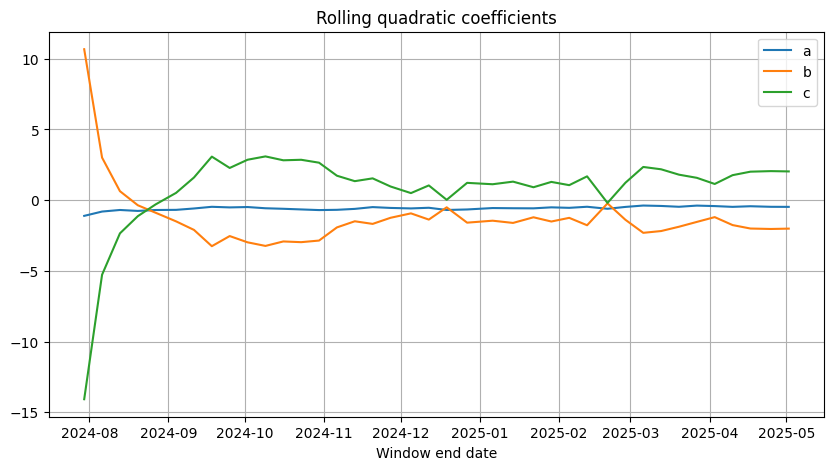

In [152]:
def plot_coefficients(coeffs):
    plt.figure(figsize=(10, 5))
    plt.plot(coeffs["window_end"], coeffs["a"], label="a")
    plt.plot(coeffs["window_end"], coeffs["b"], label="b")
    plt.plot(coeffs["window_end"], coeffs["c"], label="c")
    plt.legend()
    plt.title("Rolling quadratic coefficients")
    plt.xlabel("Window end date")
    plt.grid(True)
    plt.show()

plot_coefficients(coeffs)

In [ ]:
# {'sse_bs': 2010418.6905915753, 'sse_mv': 999403.225144182, 'gain_pct': 50.28880154063317}

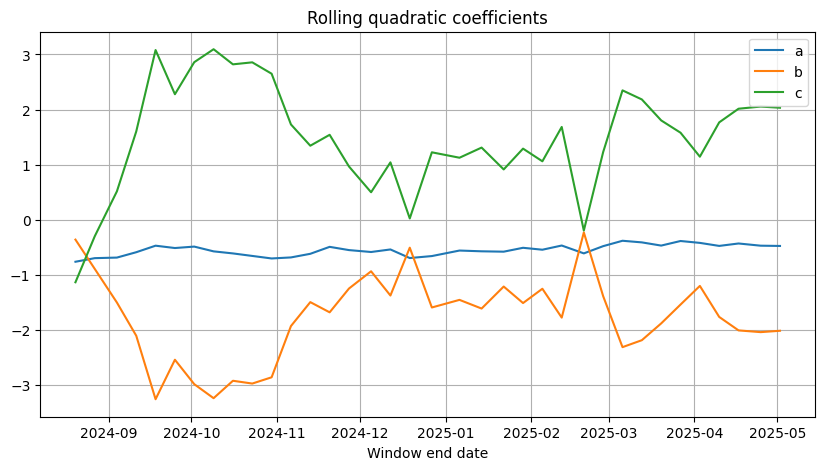

In [155]:
burn_in_windows = 3   
coeffs_report = coeffs.iloc[burn_in_windows:].copy()
plot_coefficients(coeffs_report)